In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
# Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, 
# se Y está balanceada no teste.

In [6]:
X_test = pd.read_csv("C:/Users/user/Documents/EBAC/dados/X_test")
X_train = pd.read_csv("C:/Users/user/Documents/EBAC/dados/X_train_balanced")
Y_test = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Y_test")
Y_train = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Y_train_balanced")

In [7]:
num_linhas_X_train = X_train.shape[0]
print("Número de linhas em X_train:", num_linhas_X_train)

num_linhas_X_test = X_test.shape[0]
print("Número de linhas em X_test:", num_linhas_X_test)

Número de linhas em X_train: 252
Número de linhas em X_test: 41


In [5]:
num_linhas_Y_train = Y_train.shape[0]
print("Número de linhas em Y_train:", num_linhas_Y_train)

num_linhas_Y_test = Y_test.shape[0]
print("Número de linhas em Y_test:", num_linhas_Y_test)

Número de linhas em Y_train: 252
Número de linhas em Y_test: 41


In [8]:
X_test.head(5)

,Age,Income,Number of Children,Marital_Status_Encoded,Gender_Encoded,Home_Ownership_Encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25.0,55000.0,0,1,0,1,1,0,0,0
1,48.0,87500.0,1,0,0,0,0,1,0,0
2,26.0,55000.0,1,0,0,0,1,0,0,0
3,39.0,62500.0,2,0,0,0,1,0,0,0
4,35.0,90000.0,1,0,0,0,0,1,0,0


In [9]:
X_train.head(5)

,Age,Income,Number of Children,Marital_Status_Encoded,Gender_Encoded,Home_Ownership_Encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26.0,45000.0,0,1,0,1,0,0,0,0
1,29.0,27500.0,0,1,0,1,0,0,1,0
2,25.0,62500.0,0,1,0,1,1,0,0,0
3,29.0,68000.0,2,0,0,0,0,1,0,0
4,31.0,65000.0,0,1,1,1,1,0,0,0


In [10]:
Y_test.head(5)

,Credit_Score_Encoded
0,0
1,1
2,0
3,1
4,1


In [12]:
Y_train.head(5)

,Credit_Score_Encoded
0,0
1,2
2,0
3,0
4,0


In [13]:
# Contar o numero de exemplos de cada classe em Y_Train
train_balance = Y_train.value_counts()
print("Balanceamento em Y_train:")
print(train_balance)

# Contar o numero de exemplos de cada classe em Y_test
test_balance = Y_test.value_counts()
print("Balanceamento em Y_test:")
print(test_balance)

Balanceamento em Y_train:
Credit_Score_Encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64
Balanceamento em Y_test:
Credit_Score_Encoded
1                       29
0                        6
2                        6
Name: count, dtype: int64


In [15]:
# O número de linhas em X (252) e Y (41) estao iguais em treino e teste respectivamente !!

# As variaveis estão corretas, sendo Y a nossa varíavel target (Credit_Score_Encoded) e as demais em X

# A variavel Y não está balanceada em test e isso está correto por o balanceamento ser necessário apenas na etapa de treino.

In [ ]:
# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação 
# do modelo e também como podemos melhorar nosso modelo.

In [16]:
# Imagine que você quer criar um "fluxograma inteligente" que tome decisões ou faça previsões com base em dados. 
# A Árvore de Decisão é exatamente isso! Ela aprende com os seus dados a criar uma estrutura hierárquica de perguntas (nós) e respostas (ramos) 
# que levam a uma decisão final (folha).

# O passo a passo para aplicar o algoritmo da Árvore de Decisão seria:

# Coleta de dados

# tratar dados ausentes e dados categóricos

# dividir os dados em treino e teste

# definir parametros 

# Avaliação do Modelo:

# Após treinar a árvore de decisão, é fundamental avaliar seu desempenho em dados que ela nunca viu antes (o conjunto de teste). 
# Isso nos dá uma ideia de como o modelo se generaliza para novos dados.

# Métricas de Avaliação: A escolha das métricas depende do tipo de problema:
# Classificação: Acurácia, Precisão, Recall, F1-Score, Matriz de Confusão.
# Regressão: Erro Médio Absoluto (MAE), Erro Médio Quadrático (MSE), Raiz do Erro Médio Quadrático (RMSE), R-quadrado.
# Analisar essas métricas no conjunto de teste nos ajuda a entender se o modelo está performando bem ou se está sofrendo de overfitting (decorando os dados de treinamento e performando mal em dados novos) ou underfitting (não capturando os padrões importantes nos dados).

In [17]:
# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
# Traga a acurácia para o modedlo com os dados de treino.

In [18]:
arvore_score = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

# arvore_score é o nome que escolho para o meu classificador
# 'criterion' defini o critério para medir a qualidade da divisão (usando o índice de Gini neste caso)
# 'randim_state' define a semente aleatória para garantir a reprodutibilidade dos resultados

arvore_score.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=0)

In [21]:
# Fazer previsões para os dados de treino
y_pred_train = arvore_score.predict(X_train)

# Calcular a acurácia
accuracy = accuracy_score(Y_train, y_pred_train)
print('Acurácia:', accuracy)

Acurácia: 1.0


In [22]:
# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. 
# Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [23]:
# Fazer previsões para os dados de treino
y_pred_test = arvore_score.predict(X_test)

# Calcular a acurácia
accuracy = accuracy_score(Y_test, y_pred_test)
print('Acurácia:', accuracy)

Acurácia: 0.9512195121951219


In [24]:
# A acurácia na base de testes esta em 95% de acertos, está altamente satisfatória, porém um pouco abaixo da acurácia em treino que atingiu 100%.
# normalmente existe mesmo um valor menor de acurária em teste pois obedece ao princípio de aprendizado e depois o teste com dados novos

In [ ]:
# 5) Plote a árvore de decisão.
# É possível fazer uma avaliação visual? Qual a profundidade da árvore?

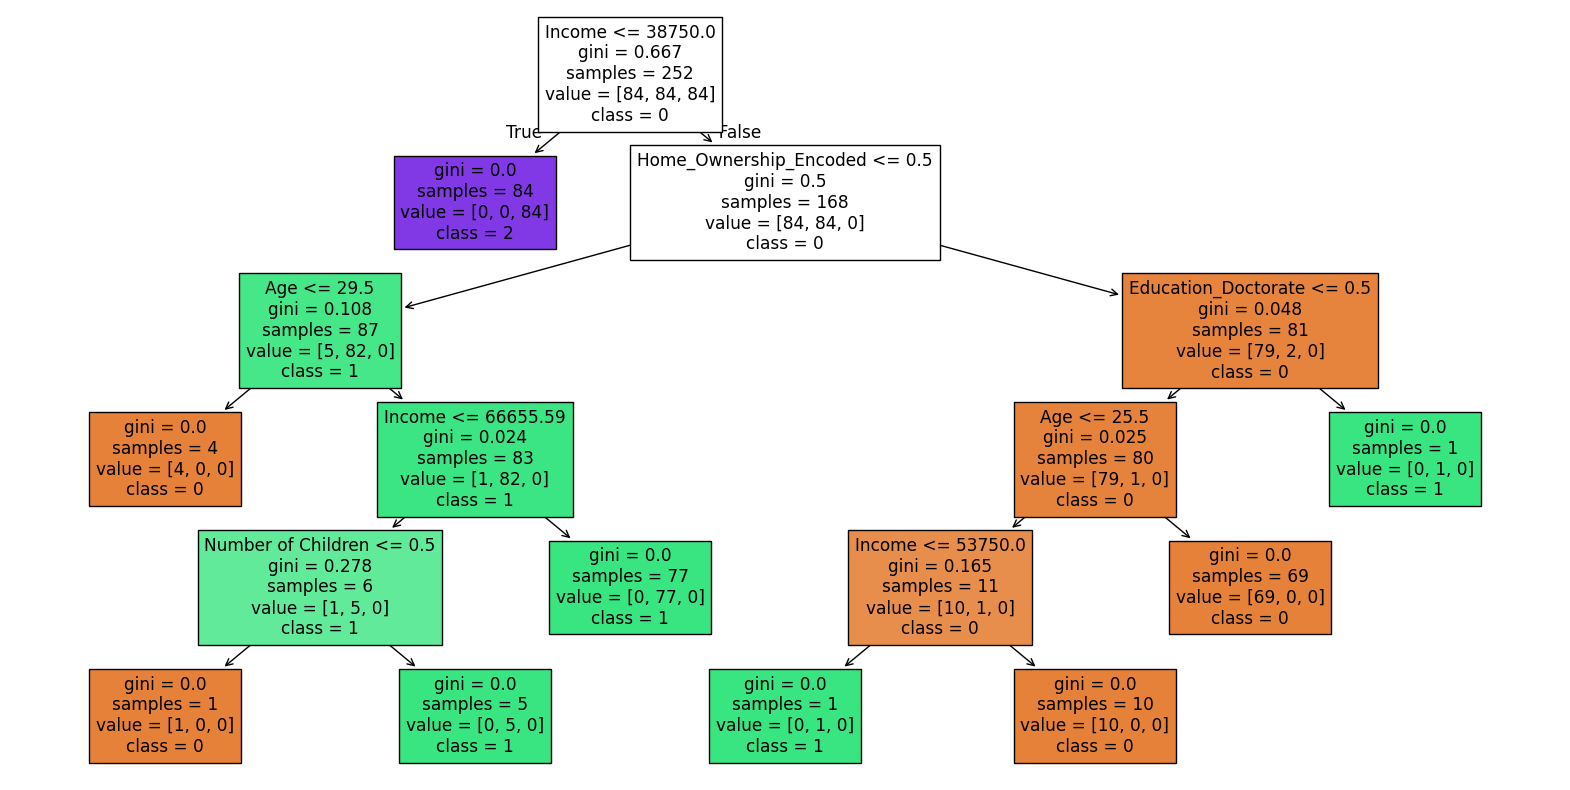

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(arvore_score, filled=True, feature_names=X_train.columns, class_names=['0', '1', '2'])
plt.show()

In [ ]:
# a arvore tem profundidade ate a 5ª camada
# é possivel interpretar o classificador, por exemplo:
# a arvore divide o dado de income <= 38750, aonde 84 amostras classificam como '2', ou seja, high score e os demais seguem
# depois divide o classificador pelo dado de 'Home_Ownership_Encoded', como <= 0.5 e isto divide em 2 ramos, os de '0' e '1'.
# isto divide em novos ramos aonde em um divide os novos ramos entre <= 29.5 anos, e no outro lado o Doutorado (Education_Doctorate)
# e assim foi-se dividindo cada vez mais os dados ate classificar todos

In [31]:
# 6) Identifique as 2 principais features do modelo.

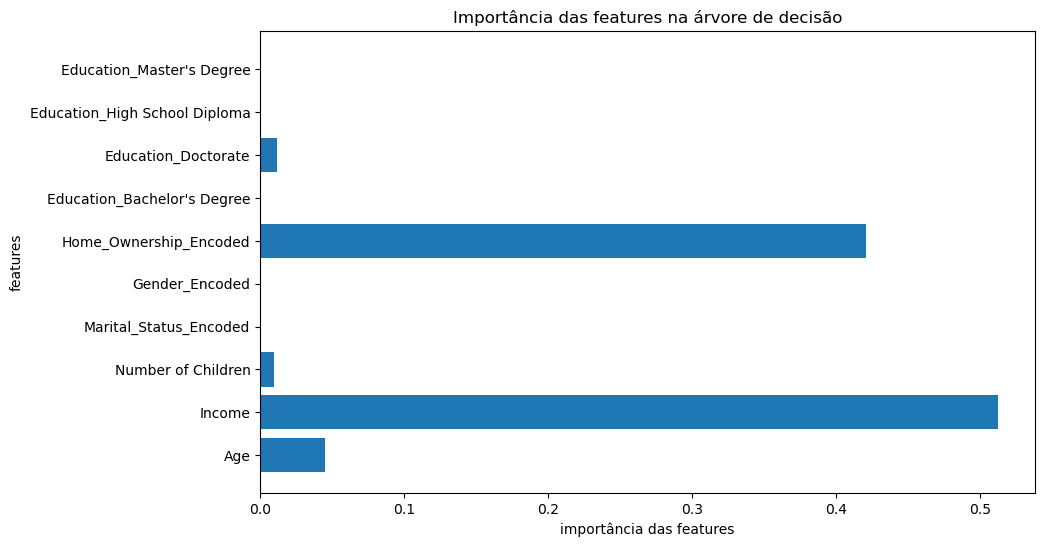

In [36]:
# Obtendo a importância das características do modelo da árvore de decisão

importancia_features = arvore_score.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancia_features)
plt.xlabel('importância das features')
plt.ylabel('features')
plt.title('Importância das features na árvore de decisão')
plt.show()

In [38]:
# 'Income' e 'Home_Ownership_Encoded' são as mais importates e isto já era esperado, pois o diagrama da árvore comecou justamente por elas, sendo
# Income a maior e a primeira a ser dividida em nós.

In [39]:
# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. 
# Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [41]:
X_train_reduzido = X_train[['Income', 'Home_Ownership_Encoded']]
X_test_reduzido = X_test[['Income', 'Home_Ownership_Encoded']]

In [42]:
arvore_score_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

arvore_score_reduzido.fit(X_train_reduzido, Y_train)

DecisionTreeClassifier(random_state=0)

In [45]:
previsoes = arvore_score.predict(X_test)

In [46]:
relatorio = classification_report(Y_test, previsoes)
print('Relatório de classificação:')
print(relatorio)

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.93      0.96        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



In [43]:
previsoes_reduzido = arvore_score_reduzido.predict(X_test_reduzido)

In [44]:
relatorio = classification_report(Y_test, previsoes_reduzido)
print('Relatório de classificação:')
print(relatorio)

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



In [47]:
# A precião aumentou consideravelmente para a classe 0 (8 pontos), reduziu 3 pontos para a classe 1 e manteve-se estavel na classe 2
# em recall diminuiu na classe 0 em 10 pontos, porém aumentou em 4 na classe 1 e manteve-se inalterada na classe 2
# f1-score diminuiu 3 pontos na classe 0, aumentou 1 na classe 1 e manteve-se inalterada na classe 2

# creio que o desempenho tenha piorado pois perdemos forca em dados como recall e f1-score que sao metricas importantes ao extremo para confiar no algoritmo em questao

In [40]:
# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). 
# Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [55]:
# Calcular o recall
from sklearn.metrics import recall_score
recall = recall_score(Y_train, y_pred_train, average='macro')
print('recall:', recall)

recall: 1.0


In [56]:
# Acredito que a arvore de decisao é mais adequada pois apresentou resultados melhores de acuracia (1.00 x 0.984) na fase de treino e 
# recall (1.00 x 0.984) em valores altamente satisfatorios, passando assim mais confianca ao algoritmo